# Perceptron — Banknote Authentication

This notebook builds a perceptron classifier for the Banknote Authentication dataset.

Each row represents a banknote, and the target is whether the banknote is genuine or forged.

## Goals

Walk through a complete classification workflow:

- Load the data
- Visualize feature separation
- Split and scale the features
- Fit a from-scratch perceptron model
- Compare the from-scratch model to scikit-learn's perceptron
- Evaluate model performance using accuracy and a confusion matrix

Evaluate the classifier using:

- Training accuracy
- Test accuracy
- Misclassifications over epochs
- Confusion matrix

Interpret how the perceptron learns by tracking its convergence over time.

## Dataset

- Source: Banknote Authentication dataset
- Size: 1,372 banknotes
- Features: 4 numerical image-based measurements:
  - Variance
  - Skewness
  - Kurtosis
  - Entropy

## Target

- The target is binary:
  - `0` = genuine
  - `1` = forged

In [3]:
import os
import urllib.request

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data") if os.path.basename(os.getcwd()) == "notebooks" else "data"

os.makedirs(DATA_DIR, exist_ok=True)

def download_if_needed(url, filename):
    """Download a CSV if it doesn't already exist locally."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {filename} from {url}")
        urllib.request.urlretrieve(url, path)
    return path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import Perceptron as SklearnPerceptron

# Our from-scratch implementation:
from mlpkg.supervised import PerceptronScratch

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load data

In [4]:
path = download_if_needed(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv",
    "banknote.csv",
)

cols = ["variance", "skewness", "kurtosis", "entropy", "class"]

df = pd.read_csv(path, header=None, names=cols)

print("Shape:", df.shape)
print("Class balance:", df["class"].value_counts().to_dict())

df.head()

Shape: (1372, 5)
Class balance: {0: 762, 1: 610}


,variance,skewness,kurtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 2. Visualize separability

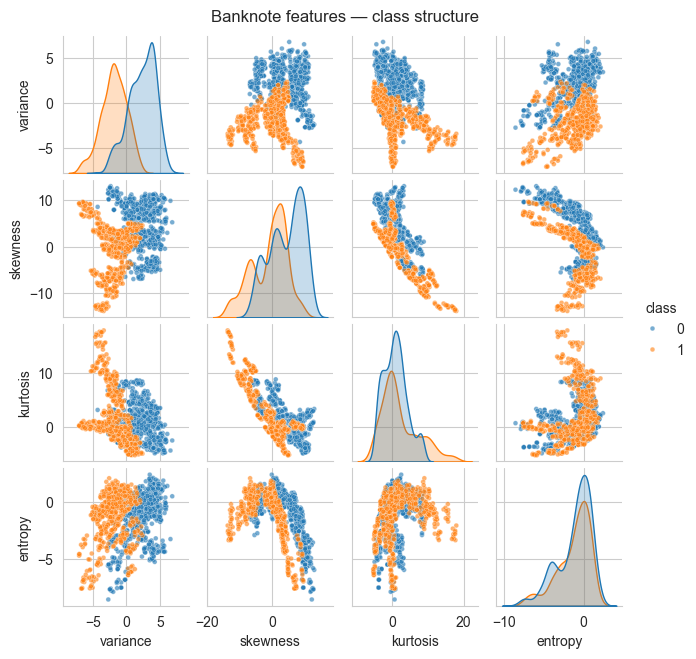

In [5]:
sns.pairplot(
    df,
    hue="class",
    height=1.6,
    plot_kws={"alpha": 0.6, "s": 12},
)

plt.suptitle("Banknote features — class structure", y=1.02)
plt.show()

Notice how the classes form mostly separable clusters — ideal for a linear classifier like the perceptron.

## 3. Split + scale

In [6]:
X = df.drop(columns="class").values
y = df["class"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

## 4. Fit our from-scratch perceptron

In [7]:
ours = PerceptronScratch(learning_rate=0.01, n_epochs=100, random_state=42)

ours.fit(X_tr_s, y_tr)

print(f"Training set accuracy: {ours.score(X_tr_s, y_tr):.4f}")
print(f"Test set accuracy:     {ours.score(X_te_s, y_te):.4f}")
print(f"Converged in {len(ours.errors_per_epoch_)} epochs")

Training set accuracy: 0.9796
Test set accuracy:     0.9767
Converged in 100 epochs


## 5. Convergence plot

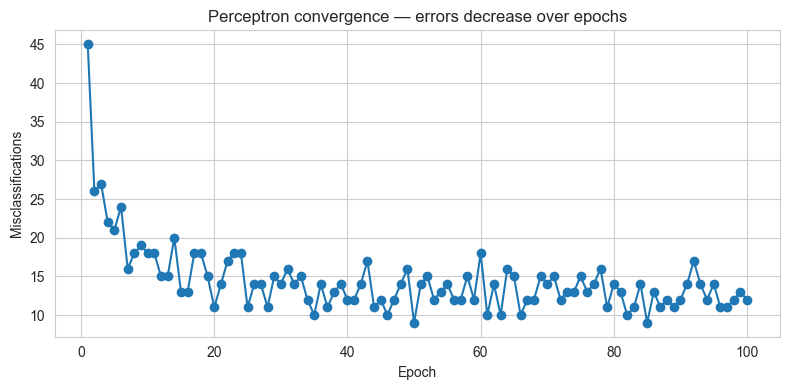

In [8]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(ours.errors_per_epoch_) + 1),
    ours.errors_per_epoch_,
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.title("Perceptron convergence — errors decrease over epochs")

plt.tight_layout()
plt.show()

If the data is linearly separable, the perceptron is *guaranteed* to converge to zero errors in finite time (Perceptron Convergence Theorem). On real-world data with overlap it may oscillate but still find a strong solution.

## 6. Compare to sklearn's Perceptron

In [9]:
ref = SklearnPerceptron(
    eta0=0.01,
    max_iter=100,
    random_state=42,
    tol=None,
)

ref.fit(X_tr_s, y_tr)

print(f"mlpkg PerceptronScratch test accuracy: {ours.score(X_te_s, y_te):.4f}")
print(f"sklearn Perceptron test accuracy:      {ref.score(X_te_s, y_te):.4f}")

mlpkg PerceptronScratch test accuracy: 0.9767
sklearn Perceptron test accuracy:      0.9854


## 7. Confusion matrix

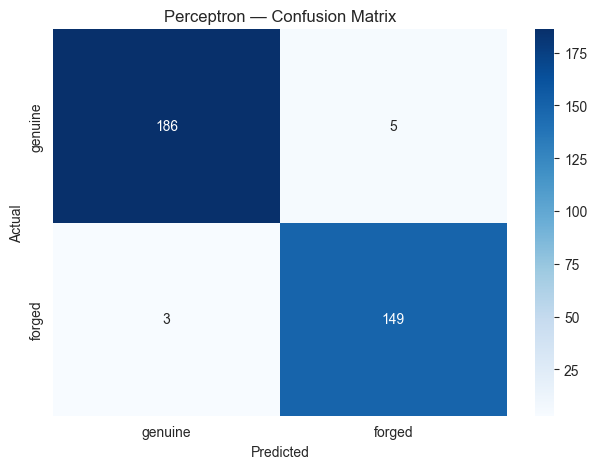

In [10]:
cm = confusion_matrix(y_te, ours.predict(X_te_s))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["genuine", "forged"],
    yticklabels=["genuine", "forged"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Perceptron — Confusion Matrix")
plt.tight_layout()
plt.show()


## Takeaways

- Our from-scratch perceptron achieves 97.67% test accuracy, which is comparable to sklearn's reference implementation at 98.54%.
- The convergence curve drops rapidly at first, meaning most learning happens in the early epochs, but it does not fully reach zero errors.
- The perceptron's strength is its simplicity. Its limitation is that it can only learn linear decision boundaries.
- Feature scaling is helpful but not strictly required for the perceptron; the algorithm can work on raw features, but scaling often improves convergence behavior.